# Homework 2: Part 1

### Deadline: Monday 11 May 2026 (by 9pm)

### Credits: 20 points


## Instructions:

- The homework is **individual**. Please include your name in the notebook.

- **Please send your compressed tar file with the following tree scheme:**

```
homework2.tar
    
    pdediffusion
    ├── metalconduction.ipynb
    ├── metalconduction.py     
    └── outputfolder
```

## Name: Terry Cevallos

## 1. Thermodynamics and Heat Conduction (12 points)

Please include your solutions to this problem within a single python notebook file: **metalconduction.ipynb**

Use appropriate numerical algorithms to study how the temperature profile in a heated metal wire evolves in time, under different initial and boundary conditions. For this, you need to numerically solve the 1D heat equation:

$$\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}$$

where $T=T(x, t)$ describes the temperature of the metal, $x$ is position, $t$ is time, and $\alpha$ is the thermal diffusivity of the metal. We will consider the following metals:

| Metal      | $\alpha$ ($\frac{mm^2}{s}$) |
|------------|------------------------------|
| Copper     | 111                          |
| Iron       | 23                           |
| Aluminum   | 97                           |
| Brass      | 34                           |
| Steel      | 18                           |
| Zinc       | 42                           |
| Lead       | 22                           |
| Titanium   | 9.8                          |
| Silver     | 165                          |
| Gold       | 127                          |
| Nickel     | 23                           |
| Tungsten   | 67                           |
| Magnesium  | 88                           |
| Tin        | 40                           |
| Platinum   | 25                           |
| Cobalt     | 26                           |

Assume that the metal wire has a length of $20\,\rm cm$, and choose the wire midpoint as the origin for the domain.

### Code design and Simulation (4 points):

Organise your code using **python classes** and carry out the following tasks:

**(a)** Place the metals and diffusivities in a python dictionary.

In [9]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Dictionary of metals and thermal diffusivity 
metal_diffusivities = {
                    'Copper': 111, 'Iron': 23, 'Aluminum': 97, 'Brass': 34, 
                    'Steel': 18, 'Zinc': 42, 'Lead': 22, 'Titanium': 9.8,
                    'Silver': 165, 'Gold': 127, 'Nickel': 23, 'Tungsten': 67,
                    'Magnesium': 88, 'Tin': 40, 'Platinum': 25, 'Cobalt': 26}

**(b)** Create a simulation initialisation routine where e.g. the mesh, the initial conditions, and the boundary conditions are all set up.

- The **Initial Condition** sets the initial temperature profile in degrees Celsius to be:

    $T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2$

where $x$ is in units of $\rm cm$. 

- The **Boundary Conditions** keep the temperatures at the edges of the metal wire fixed at a temperature of $25\,\rm C$. 

    $T(-10\,{\rm cm}, t) = T(+10\,{\rm cm}, t) = 25\,\rm C$

In [11]:
# Defien a function to set the initialization routine
def initialisation_routine(metal, h):
    
    alpha = metal_diffusivities[metal] * 0.01 #cm^2/s
    l = 10
    # Define space vector
    x = np.arange(-l, l + h, h)
    # Numbers of points in x
    n = len(x)
    # Fix ICs/BC
    T_o = 175 - 50 * np.cos(np.pi * x / 5) - x**2
    T_b = 25.0
    T_o[0] = T_b
    T_o[-1] = T_b
    
    return x, T_o, alpha, n, T_b

**(c)** Construct a Crank-Nicolson algorithm to simulate **the evolution of an initial temperature profile** and find the **time in seconds at which thermal equilibrium is reached** in an input metal wire (from the dictionary). **Hint:** You need to define some criteria to determine thermal equilibrium.

In [12]:
# Define a function to implement Crank Nicolson method
def crank_nicolson(metal, h, k , tol):

    # Call the previous function
    x, T_o, alpha, n, T_b = initialisation_routine(metal, h)
    # Define the parameter r
    r_factor = (alpha * k) / h**2

    # Define the implicit matrix
    D1_matrix_0 = np.diag([2 + 2*r_factor] * (n - 2), 0)
    D1_matrix_n = np.diag([-r_factor] * (n - 3), -1)
    D1_matrix_p = np.diag([-r_factor] * (n - 3), +1)
    D1_matrix = D1_matrix_0 + D1_matrix_n + D1_matrix_p

    # Define the explicit matrix
    D2_matrix_0 = np.diag([2 - 2*r_factor] * (n - 2), 0)
    D2_matrix_n = np.diag([r_factor] * (n - 3), -1)
    D2_matrix_p = np.diag([r_factor] * (n - 3), +1)
    D2_matrix = D2_matrix_0 + D2_matrix_n + D2_matrix_p
    # Define number of total steps
    max_steps = 100000 

    # Define a T matrix with ICs/BC
    T = np.zeros((len(x), max_steps))
    T[:, 0] = T_o # ICs
    T[0, :] = T_b # BC
    T[-1, :] = T_b # BC

    t = [0]
    thermal_t = 0
    equilibrium = False
    j = 0
    # Run the loop until the approach to the thermal equilibrium
    while not equilibrium and j < max_steps:
        
        # Add initial conditions to initial b vector
        b = T[1:-1, j].copy()     
        
        b = np.dot(D2_matrix, b)
        b[0] = b[0] + r_factor * (T[0, j+1] + T[0, j])
        b[-1] = b[-1] + r_factor * (T[-1, j+1] + T[-1, j])
        
        # Solve implicit matrix
        T[1:-1, j+1] = np.linalg.solve(D1_matrix, b)           
        
        # Equilibrium check
        if np.max(np.abs(T[:, j+1] - T[:, j])) < tol:  
            thermal_t = t[-1] 
            equilibrium = True
            print(f'Thermal Equilibrium at t = {thermal_t:.3f} [s]')

        # Store into the t list  
        t.append(t[-1] + k)
        j = j + 1

    # Update T matrix
    T = T[:, :j + 1]  

    return  x, T, t, thermal_t

**(d)** Pick **two metal wires** from the dictionary and run both simulations using your Crank-Nicolson algorithm. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of each metal wire versus $x$ at a few selected times.

### Test with Steel

In [13]:
# Define parameters
metal_1 = "Steel"
h = 0.1
k = 0.1
tol = 1e-4
# Call the function
x, T_1, t, thermal_t = crank_nicolson(metal_1, h, k, tol)

Thermal Equilibrium at t = 1493.600 [s]


In [14]:
# Define sections
#print(T_1.shape)
T1_shape = T_1.shape[1]
evolution_line = (T1_shape-1) // 50

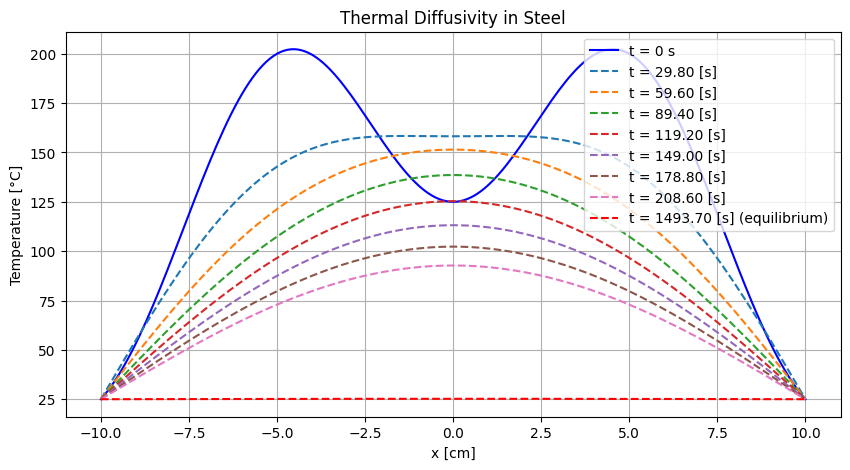

In [15]:
# Plot settings
plt.figure(figsize=(10,5))
plt.plot(x, T_1[:, 0], 'b-', label='t = 0 s')
for i in range(1, 8):
    idx = i * evolution_line    
    plt.plot(x, T_1[:, idx], '--', label=f't = {t[idx]:.2f} [s]')
plt.plot(x, T_1[:, -1], 'r--', label=f't = {t[-1]:.2f} [s] (equilibrium)')
plt.xlabel('x [cm]')
plt.ylabel('Temperature [°C]')
plt.title(f'Thermal Diffusivity in {metal_1}')
plt.legend(loc='upper right')
plt.grid()
plt.show()

### Test with Silver

In [16]:
# Define parameters
metal_2 = "Silver"
h = 0.1
k = 0.1
tol = 1e-4
# Call the function
x, T_2, t, thermal_t = crank_nicolson(metal_2, h, k, tol)
#print(T.shape)

Thermal Equilibrium at t = 217.400 [s]


In [17]:
# Define sections
#print(T_1.shape)
T2_shape = T_2.shape[1]
evolution_line_2 = (T2_shape-1) // 60

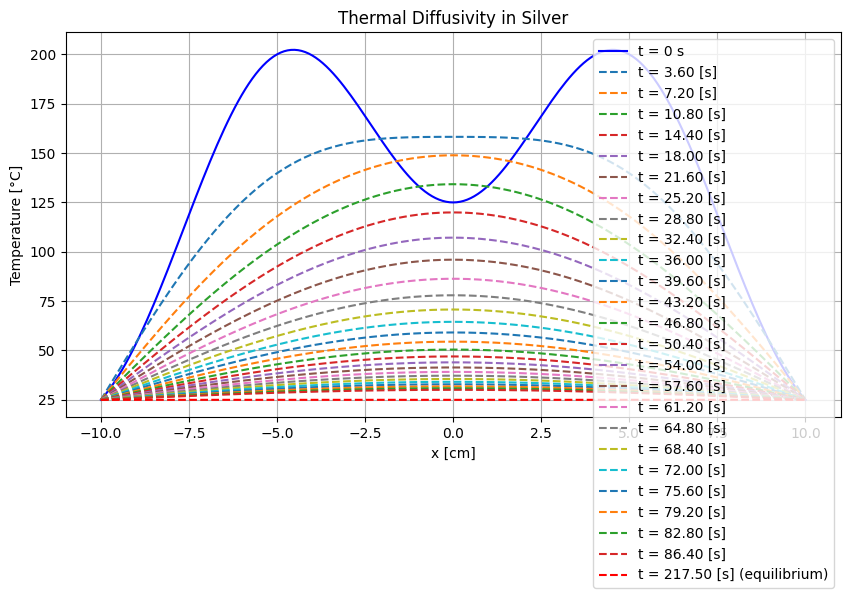

In [18]:
# Plot settings
plt.figure(figsize=(10,5))
plt.plot(x, T_2[:, 0], 'b-', label='t = 0 s')
for i in range(1, 25):
    idx = i * evolution_line_2    
    plt.plot(x, T_2[:, idx], '--', label=f't = {t[idx]:.2f} [s]')
plt.plot(x, T_2[:, -1], 'r--', label=f't = {t[-1]:.2f} [s] (equilibrium)')
plt.xlabel('x [cm]')
plt.ylabel('Temperature [°C]')
plt.title(f'Thermal Diffusivity in {metal_2}')
plt.legend(loc='upper right')
plt.grid()
plt.show()


### Joblib Parallelisation (3 points)

**(e)** Imagine we wish to run several simulations in parallel for the metals included in the dictionary. Within the **metalconduction.ipynb** notebook, create a routine that uses ```joblib``` to parallelise the simulation executions in $n$ CPUs.

In [19]:
# # Import libraries
from joblib import Parallel, delayed, cpu_count
import time

In [20]:
# Parallel function
def parallel_simulation(dict_metal, h, k, tol, n_cpu):
    
    # Get the name of the metals from the dictionary 
    metal_name = dict_metal.keys()
    # Store into a list
    metal_list = list(metal_name)

    # Time stamp
    start = time.time()
    # Call joblib
    Parallel(n_jobs=n_cpu)(delayed(crank_nicolson)(metal, h, k, tol) for metal in metal_list)
    # Time stamp
    end = time.time()
    exec_time = end - start

    return exec_time

In [21]:
# Serial function
def serial_simulation(dict_metal, h, k, tol):

    # Time stamp
    start = time.time()
    result_serial = {}

    # Serial loop
    for metal in dict_metal.keys():        
        # Call Crank Nicolson function
        res = crank_nicolson(metal, h, k, tol)
        result_serial[metal] = res
    
    # Time stamp
    end = time.time()
    exec_time = end - start

    return exec_time


**(f)** Test your implementation by running $2$ simulations ($1$ for Platinum and $1$ for Cobalt) first in serial and then in parallel (simultaneously). For the serial run, $n=1$ CPU core. For the parallel run, $n=2$ CPU cores. The time should go down. **Hint:** You need to add time stamps to quantify and return log files with the execution times. 

In [22]:
# Simulation dictionary
metal_simulation = {"Platinum": 25, "Cobalt": 26}

In [23]:
# Call Serial function
t_serial = serial_simulation(metal_simulation, 0.1, 0.1, 1e-4)
# Call Parallel function
t_parallel = parallel_simulation(metal_simulation, 0.1, 0.1, 1e-4, 2)
print(f'Time Serial: {t_serial:.4f} s')
print(f'Time Parallel: {t_parallel:.4f} s')

Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Time Serial: 5.6790 s
Time Parallel: 4.5582 s


**(g)** Make a scaling plot showing (serial and parallel) execution times in the $Y$ axis versus the number of CPU cores ($n$) in the $X$ axis.

In [24]:
# Prob for n cores
n_cpu = cpu_count()
# List of total number of cores
cores_list = list(range(1, n_cpu + 1))
t_parallel = []
# Loop for number of cpu
for n in cores_list:
    # Pasamos el diccionario grande aquí
    t_p = parallel_simulation(metal_simulation, 0.1, 0.1, 1e-4, n_cpu=n)
    t_parallel.append(t_p)

Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1091.300 [s]
Thermal Equilibrium at t = 1128.600 [s]
Thermal Equilibrium at t = 1128.600 [s]


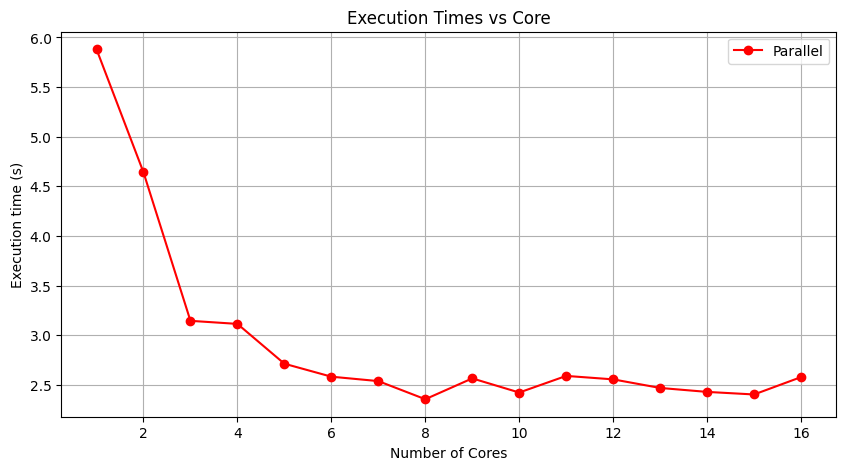

In [25]:
# Scaling Plot
plt.figure(figsize=(10, 5))
plt.plot(cores_list, t_parallel, 'r-o', label='Parallel')
#plt.plot(cores_list, t_serial, 'g-o', label='Serial')
plt.title('Execution Times vs Core')
plt.xlabel('Number of Cores')
plt.ylabel('Execution time (s)')
plt.legend()
plt.grid()
plt.show()

#### For this plot, I considered using all the cores of my computer to obtain a better visualization of the time variation with respect to the number of cores. I did indeed obtain the expected behavior, with time decreasing as the process becomes parallelized. However, there is a limit beyond which the number of cores, specifically 7 cores, is no longer efficient.

### HPC execution (3 points):

**(h)** Convert your notebook code into a script called: **metalconduction.py**. Then, copy it to the CEDIA cluster, reserve computing resources (e.g. $16$ CPU cores), then run your code in serial and parallel for all the $16$ metals at increasing $n$ (e.g. $1$, $2$, $4$, $8$, $16$ CPU cores). Export log files from each run, so that the thermal equilibrium times and simulation run times can be analysed later. Include the log files and all your SLURM job scripts in the **outputfolder.**

```Python
# Scrip to solve the 1D heat equation by Crank-Nicolson

#Import libraries

import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from joblib import Parallel, delayed, cpu_count

# Dictionary of metals and thermal diffusivity 
metal_diffusivities = {
                    "Copper": 111, "Iron": 23, "Aluminum": 97, "Brass": 34, 
                    "Steel": 18, "Zinc": 42, "Lead": 22, "Titanium": 9.8,
                    "Silver": 165, "Gold": 127, "Nickel": 23, "Tungsten": 67,
                    "Magnesium": 88, "Tin": 40, "Platinum": 25, "Cobalt": 26}


class heatDiffusion:
    def __init__(self, metal, h=0.1, k=0.1, tol=1e-3):
        '''
        Define the heat diffusion class.        
        metal (str): The type of metal to analyze.
        h (float): The spatial step size in cm (default: 0.1).
        k (float): The time step size in seconds (default: 0.1).
        tol (float): The tolerance for thermal equilibrium (default: 1e-3). 
        '''
    
        # Error validation
        if metal not in metal_diffusivities:
            raise ValueError (f"Invalid metal:'{metal}'")
        # Define inputs
        self.metal = metal
        self.alpha = metal_diffusivities[metal] * 0.01 # convet in cm^2/s
        self.h = h
        self.k = k
        self.tol = tol
        self.l = 10.0 #Length of the metal cm
        self.max_steps = 100000

    def initialization_routine(self):
        '''
        Define the spatial grid, initial temperature distribution, 
        and BCs.        
        x (numpy array): Spatial grid points.
        T_o (numpy array): Initial temperature.
        n (int): Number of spatial points.
        T_b (float): Boundary temperature.
        '''
        # Define space vector
        x = np.arange(-self.l, self.l + self.h, self.h)
        # Number of points inside to the bar
        n = len(x) 
        # Set the initial condition 
        T_o = 175 - 50 * np.cos((np.pi * x) / 5) - x**2
        # Set boundary conditions
        T_b = 25
        T_o[0] = T_b
        T_o[-1] = T_b

        return x , T_o, n, T_b

    def crank_nicolson(self):
        '''
        Define the Crank-Nicolson discretization method.
        x (numpy array): Spatial grid points.
        T (numpy array): Temperature distribution over time.
        t (list): Time points.
        thermal_t (float): Time to reach thermal equilibrium in minutes.
        '''
        # Call the init function
        x, T_o, n, T_b = self.initialization_routine()
        # Define r factor             
        r_factor = (self.alpha * self.k) / (self.h**2)

        # Define the implicit matrix
        D1_matrix_0 = np.diag([2 + 2*r_factor] * (n - 2), 0)
        D1_matrix_n = np.diag([-r_factor] * (n - 3), -1)
        D1_matrix_p = np.diag([-r_factor] * (n - 3), +1)
        D1_matrix = D1_matrix_0 + D1_matrix_n + D1_matrix_p

        # Define the explicit matrix
        D2_matrix_0 = np.diag([2 - 2*r_factor] * (n - 2), 0)
        D2_matrix_n = np.diag([r_factor] * (n - 3), -1)
        D2_matrix_p = np.diag([r_factor] * (n - 3), +1)
        D2_matrix = D2_matrix_0 + D2_matrix_n + D2_matrix_p

        # Define a T matrix with ICs/BC
        T = np.zeros((len(x), self.max_steps))
        T[:, 0] = T_o # ICs
        T[0, :] = T_b # BC
        T[-1, :] = T_b # BC

        t = [0]
        thermal_t = 0
        equilibrium = False
        j = 0
        # Run the loop until the approach to the thermal equilibrium
        while not equilibrium and j < self.max_steps:
            
            b = T[1:-1, j].copy()     
            
            b = np.dot(D2_matrix, b)
            b[0] = b[0] + r_factor * (T[0, j+1] + T[0, j])
            b[-1] = b[-1] + r_factor * (T[-1, j+1] + T[-1, j])        
            
            # Solve implicit matrix
            T[1:-1, j+1] = np.linalg.solve(D1_matrix, b)           
            
            # Equilibrium check
            if np.max(np.abs(T[:, j+1] - T[:, j])) < self.tol:  
                thermal_t = t[-1]
                equilibrium = True
                #print(f'Thermal Equilibrium at t = {thermal_t:.3f} [s]')

            # Store into the t list  
            t.append(t[-1] + self.k)
            j = j + 1

        # Update T matrix
        T = T[:, :j + 1]  

        return  x, T, t, thermal_t
    
def execution_rutine(metal):
    '''
    Define the execution routine for each metal.
    metal (str): The type of metal to analyze.'''

    # Call the function 
    _, _, _, thermal_t = heatDiffusion(metal).crank_nicolson()
    print({'metal': metal, 'thermal_t': round(thermal_t, 4)})
    return metal, thermal_t

if __name__ == "__main__":

    if len(sys.argv) > 1:
        n_cores = int(sys.argv[1])
    else:
        n_cores = 1

    list_metals = list(metal_diffusivities.keys())        
    print(f'Number of cores{n_cores}')   

    # Time stamp
    start_time = time.time()
    
    if n_cores == 1:
        results = [execution_rutine(m) for m in list_metals]
    else:
        results = Parallel(n_jobs=n_cores)(delayed(execution_rutine)(m) for m in list_metals)

    # Time stamp
    end_time = time.time()
    total_time = end_time - start_time        
    
    print(f'Execution time {total_time:.4f}')
```


**(i)** Within the **metalconduction.ipynb** notebook, create a routine to open the log files produced by the serial run and all the different parallel runs on the HPC cluster.

In [26]:
# Import libraries
import pandas as pd
import os
import ast

In [27]:
# Define the path of the data
path = '/home/tpaulcr/Documentos/FC2/pdediffusion/outputfolder/'

In [28]:
# List to store metals
metals_list = []
with open(os.path.join(path, 'log_n1.txt'), 'r') as f:
    for linea in f:
        linea = linea.strip()
        # Solo procesamos si la línea es un diccionario
        if linea.startswith('{') and linea.endswith('}'):
            metals_list.append(ast.literal_eval(linea))

# Create a DataFrame
df = pd.DataFrame(metals_list)
df.columns = ['Metal', 'Equilibrium_Time']
# Check the DataFrame
#print(df)

In [29]:
# Loop to get numbers of cores and times
cores = [1, 2, 4, 8, 16]
t_cluster = []
for n in cores:
    file = os.path.join(path, f'log_n{n}.txt')
    with open(file, 'r') as f:
        lineas = f.readlines()        
        for linea in reversed(lineas):
            if 'Execution time' in linea:
                # Extraemos el número final
                t_exec = float(linea.split(':')[-1].strip())
                t_cluster.append(t_exec)
                break

In [30]:
# Crear DataFrame de rendimiento
df_cluster = pd.DataFrame({
                        'Cores': cores,
                        'Execution time': t_cluster})
# Check the DataFrame
#print(df_cluster)

**(j)** Make a new scaling plot for the HPC cluster showing the executions times on the Y-axis and number of cores on the X-axis. Display also the **Amdahl's (theoretical) law**. 

##### Reference https://en.wikipedia.org/wiki/Amdahl%27s_law

In [31]:
# Get the data for plotting
n_cores = df_cluster['Cores']
t_execution = df_cluster['Execution time']
# Time of the serial execution
t_serial = t_execution.iloc[0]  

#### Amdahl's law

In [32]:
# Define the Amdahl's Law 
# We assume that the optimized is 95%
time_optimized = 0.95
speedup_optimized = n_cores 

# Define the overall speedup
speedup_overall = 1 / ((1 - time_optimized) + (time_optimized / speedup_optimized))

# Theorical time expected
t_theoretical = t_serial / speedup_overall

#### Ideal times 

##### Reference https://github.com/wbandabarragan/computational-physics-2/blob/main/unit-3/307-joblib-practice-problem.ipynb

In [33]:
i_arr = np.full(n_cores.shape, t_execution[0])/n_cores

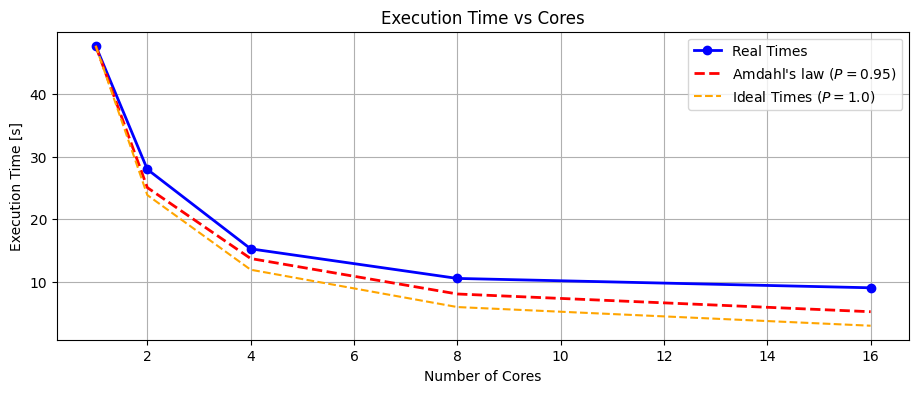

In [34]:
# Create the plot
plt.figure(figsize=(11, 4))
# Plot real time
plt.plot(n_cores, t_execution,'o-', linewidth=2, label='Real Times', color='blue')
# Plot Amdahl's Law
plt.plot(n_cores, t_theoretical, '--', linewidth=2, label='Amdahl\'s law ($P=0.95$)', color='red')
# Ideal time
plt.plot(n_cores, i_arr, '--', color='orange', label='Ideal Times ($P=1.0$)')
# Settings of the plot
plt.xlabel('Number of Cores')
plt.ylabel('Execution Time [s]')
plt.title('Execution Time vs Cores')
plt.grid()
plt.legend()
plt.show()

### Analysis (2 points):

**(k)** Compare the Amdahl's law to your results and comment on the findings (e.g. does your parallelisation follow Amdahl's law? Why yes or no?)

#### As can be seen in the plot of execution time vs. cores, the behavior is similar to Amdahl's Law. However, a difference between the two can be observed, and this is because Amdahl's Law considers the ideal execution case; that is, it does not account for how parallelization tends to increase execution time due to communication between cores to collect information once processed, as well as the dissipation of energy in the form of heat.

**(l)** Make a plot showing the thermal equilibrium times versus diffusivities. Do the different thermal equilibrium times for distinct metals influence how ```joblib``` handles parallelisation?

In [35]:
# Get the diffusivity for each metal in the DataFrame using the dictionary
df['Diffusivity'] = df['Metal'].map(metal_diffusivities)
diffusivities = df['Diffusivity'] * 0.01 # Convert to cm^2/s
equilibrium_times = df['Equilibrium_Time']
# Check the DataFrame
#print(df[['Metal', 'Diffusivity', 'Equilibrium_Time']].head())

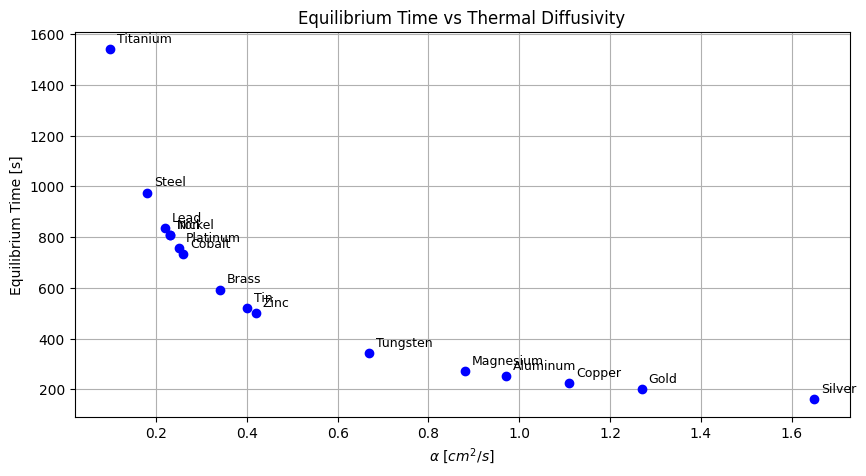

In [36]:
# Plot settings
plt.figure(figsize=(10, 5))
plt.scatter(diffusivities, equilibrium_times, color='blue', zorder=3)
# Add labels for each metal
for i, metal in enumerate(df['Metal']):
    plt.annotate(metal, 
                 (diffusivities[i], equilibrium_times[i]),
                 textcoords="offset points", 
                 xytext=(5, 5), 
                 fontsize=9)
plt.title('Equilibrium Time vs Thermal Diffusivity')
plt.xlabel(r'$\alpha$ [$cm^2/s$]')
plt.ylabel('Equilibrium Time [s]')
plt.grid()
plt.show()

#### I think jobblib can impact the total execution time since it has to collect information from each core. However, it doesn't affect the time to reach thermal equilibrium because thermal equilibrium only depends on the alpha factor for each metal, which can increase or decrease heat diffusion and therefore the time to reach thermal equilibrium.